# Glosario Interactivo — Conceptos Introductorios de ML

**Módulo 1 — Aprendizaje Supervisado** | DSRP Machine Learning Engineering

---

> 📖 Este notebook es un **glosario de referencia**. Cada concepto incluye una definición concisa y un bloque de código que lo ilustra visualmente.  
> No es necesario ejecutarlo de principio a fin — úsalo como consulta cuando encuentres un término desconocido en los otros notebooks.

### Índice
1. [Residuos](#1)
2. [MCO — Mínimos Cuadrados Ordinarios](#2)
3. [MLE — Máxima Verosimilitud](#3)
4. [Distribuciones de probabilidad](#4)
5. [Supuestos estadísticos](#5)
6. [Sesgo y Varianza (Bias-Variance Tradeoff)](#6)
7. [Overfitting y Underfitting](#7)
8. [Términos de clasificación (TP, FP, TN, FN)](#8)
9. [Accuracy, Precision, Recall y F1 — detalle del trade-off](#9)
10. [Log-Loss / Cross-Entropy](#10)
11. [Odds y Log-Odds](#11)
12. [Curva ROC y ROC-AUC](#12)
13. [PR-AUC — Curva Precisión-Recall](#13)
14. [Derivada de la sigmoide — usos prácticos](#14)
15. [Gini e Impureza de Entropía — árboles de clasificación](#15)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


---
<a id='1'></a>
## 1. Residuos

**Definición:** El **residuo** de una observación es la diferencia entre el valor real $y_i$ y el valor predicho $\hat{y}_i$ por el modelo:

$$e_i = y_i - \hat{y}_i$$

Los residuos son la "huella" de los errores del modelo. Su análisis permite detectar:
- Si el modelo **subestima o sobreestima** sistemáticamente en alguna zona.
- Si los errores son **aleatorios** (buen modelo) o tienen algún patrón (modelo incompleto).

| Residuo | Significado |
|---------|-------------|
| $e_i > 0$ | El modelo predijo **menos** de lo real |
| $e_i < 0$ | El modelo predijo **más** de lo real |
| $e_i = 0$ | Predicción perfecta para esa observación |

<>:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/tmp/ipykernel_503626/2483334427.py:10: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axes[0].plot(x, y_pred, 'b-', lw=2, label='Modelo ($\hat{y}$)')


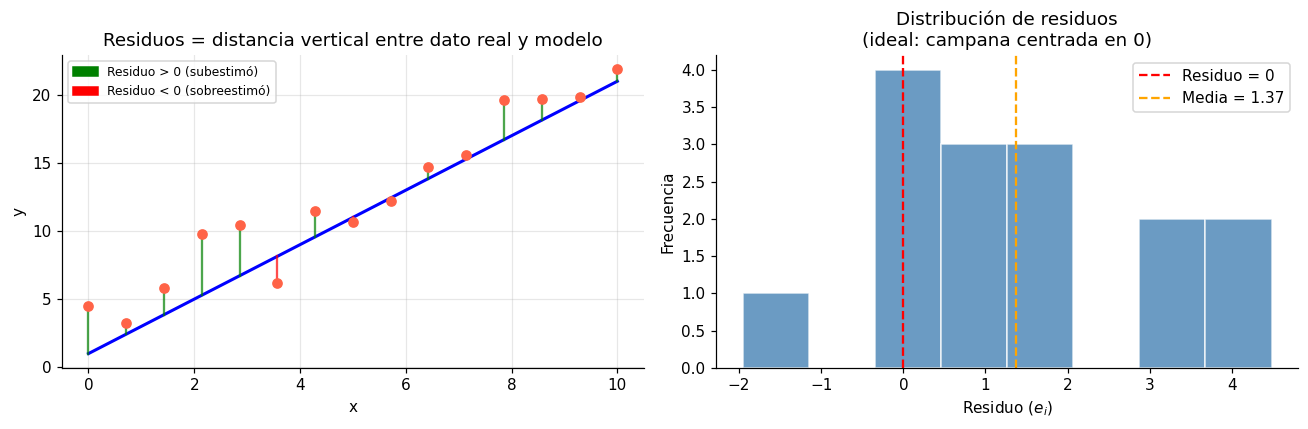

In [5]:
np.random.seed(0)
x = np.linspace(0, 10, 15)
y_real = 2 * x + 1 + np.random.normal(0, 2, len(x))  # datos reales con ruido
y_pred = 2 * x + 1                                    # línea de regresión (modelo)
residuos = y_real - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Izquierda: residuos como segmentos verticales ---
axes[0].plot(x, y_pred, 'b-', lw=2, label='Modelo ($\hat{y}$)')
axes[0].scatter(x, y_real, color='tomato', zorder=5, label='Datos reales ($y$)')
for xi, yr, yp in zip(x, y_real, y_pred):
    # Cada segmento vertical = residuo de ese punto
    color = 'green' if yr > yp else 'red'
    axes[0].plot([xi, xi], [yp, yr], color=color, lw=1.5, alpha=0.7)
axes[0].set_title('Residuos = distancia vertical entre dato real y modelo')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
pos_patch = mpatches.Patch(color='green', label='Residuo > 0 (subestimó)')
neg_patch = mpatches.Patch(color='red',   label='Residuo < 0 (sobreestimó)')
axes[0].legend(handles=[pos_patch, neg_patch], fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Derecha: distribución de residuos (queremos campana centrada en 0) ---
axes[1].hist(residuos, bins=8, edgecolor='white', color='steelblue', alpha=0.8)
axes[1].axvline(0, color='red', ls='--', label='Residuo = 0')
axes[1].axvline(residuos.mean(), color='orange', ls='--', label=f'Media = {residuos.mean():.2f}')
axes[1].set_title('Distribución de residuos\n(ideal: campana centrada en 0)')
axes[1].set_xlabel('Residuo ($e_i$)'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()


---
<a id='2'></a>
## 2. MCO — Mínimos Cuadrados Ordinarios (OLS)

**Definición:** MCO es el método que usa la **regresión lineal** para encontrar los coeficientes $\beta$ que minimizan la **suma de los residuos al cuadrado**:

$$\text{SCR} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Se elevan al cuadrado para que residuos positivos y negativos no se cancelen, y para penalizar más los errores grandes.

La solución exacta en forma matricial es: $\hat{\beta} = (X^\top X)^{-1} X^\top y$

**¿Por qué "ordinarios"?** Existen variantes más complejas:
| Método | Cuándo se usa |
|--------|---------------|
| **MCO (OLS)** | Caso base — varianza constante, sin correlaciones entre errores |
| **GLS** (Mínimos Cuadrados Generalizados) | Cuando los errores tienen estructura de correlación conocida |
| **WLS** (Mínimos Cuadrados Ponderados) | Cuando algunas observaciones son más confiables que otras |
| **Ridge / Lasso** | MCO con regularización — evita sobreajuste con muchos predictores |

In [ ]:
np.random.seed(1)
x = np.linspace(0, 5, 20)
y = 1.5 * x + 2 + np.random.normal(0, 1, len(x))

# Probamos diferentes pendientes y calculamos la SCR (suma de cuadrados de residuos)
# MCO encuentra la pendiente que hace mínima esa suma
pendientes = np.linspace(0, 3, 200)
intercepto = y.mean() - pendientes * x.mean()  # intercepto óptimo dado cada pendiente
scr = [np.sum((y - (b * x + b0))**2) for b, b0 in zip(pendientes, intercepto)]

b_optimo = pendientes[np.argmin(scr)]
b0_optimo = y.mean() - b_optimo * x.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Izquierda: la recta óptima vs datos ---
axes[0].scatter(x, y, color='tomato', zorder=5, label='Datos')
axes[0].plot(x, b_optimo * x + b0_optimo, 'b-', lw=2,
             label=f'MCO: $\hat{{y}}$ = {b_optimo:.2f}x + {b0_optimo:.2f}')
# Cuadrados de residuos como áreas visuales
for xi, yi in zip(x, y):
    yhat = b_optimo * xi + b0_optimo
    lado = abs(yi - yhat)
    sq = plt.Rectangle((xi - lado/2, min(yi, yhat)), lado, lado,
                        fill=True, alpha=0.15, color='purple')
    axes[0].add_patch(sq)
axes[0].set_title('MCO: minimiza la SUMA de los cuadrados de los residuos\n(cuadrados morados = lo que se minimiza)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# --- Derecha: función de costo — mínimo en la pendiente óptima ---
axes[1].plot(pendientes, scr, color='steelblue', lw=2)
axes[1].axvline(b_optimo, color='red', ls='--', label=f'Pendiente óptima = {b_optimo:.2f}')
axes[1].scatter([b_optimo], [min(scr)], color='red', s=80, zorder=5)
axes[1].set_title('Suma de Cuadrados de Residuos\nvs. pendiente del modelo')
axes[1].set_xlabel('Pendiente $\\beta_1$'); axes[1].set_ylabel('SCR')
axes[1].legend()

plt.tight_layout()
plt.show()


---
<a id='3'></a>
## 3. MLE — Máxima Verosimilitud (Maximum Likelihood Estimation)

**Definición:** MLE es un método alternativo para estimar los parámetros de un modelo. En lugar de minimizar errores al cuadrado, busca los parámetros que hacen que los datos observados sean **lo más probables posible**.

**Idea intuitiva:** si lanzas una moneda 10 veces y sale cara 7 veces, ¿cuál es la probabilidad de cara más verosímil? MLE respondería: 7/10 = 0.7, porque ese valor hace que el resultado observado (7 caras en 10 lanzamientos) sea el más probable de todos los posibles.

La **función de verosimilitud** $\mathcal{L}(\theta)$ mide qué tan probable es el conjunto de datos dado un parámetro $\theta$:

$$\mathcal{L}(\theta) = P(\text{datos} \mid \theta) = \prod_{i=1}^n P(y_i \mid x_i, \theta)$$

En la práctica se maximiza el **log de la verosimilitud** (log-likelihood) para evitar underflow numérico al multiplicar probabilidades pequeñas.

| | MCO | MLE |
|---|---|---|
| **Usado en** | Regresión lineal | Regresión logística, modelos probabilísticos |
| **Qué optimiza** | Minimiza $\sum e_i^2$ | Maximiza $P(\text{datos} \mid \theta)$ |
| **Requiere supuesto de normalidad** | Sí (para inferencia) | No necesariamente |
| **Resultado con datos normales** | Son equivalentes | Son equivalentes |

In [ ]:
# Ejemplo: estimar la media de una distribución normal con MLE
# MLE dice que la mejor estimación de la media es simplemente... la media muestral.
# Aquí lo verificamos visualmente.

np.random.seed(42)
datos = np.random.normal(loc=5.0, scale=1.5, size=30)  # datos reales (media verdadera = 5)

# Probamos distintos valores de mu y calculamos el log-likelihood
mu_candidatos = np.linspace(2, 8, 300)
sigma_fija = datos.std()  # asumimos sigma conocida para simplificar

log_likelihoods = [
    np.sum(stats.norm.logpdf(datos, loc=mu, scale=sigma_fija))
    for mu in mu_candidatos
]

mu_mle = mu_candidatos[np.argmax(log_likelihoods)]  # máximo del log-likelihood

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Izquierda: datos y distribución bajo el parámetro MLE ---
xr = np.linspace(0, 10, 200)
axes[0].hist(datos, bins=10, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Datos observados')
axes[0].plot(xr, stats.norm.pdf(xr, mu_mle, sigma_fija), 'r-', lw=2,
             label=f'Distribución MLE (μ={mu_mle:.2f})')
axes[0].axvline(datos.mean(), color='orange', ls='--', label=f'Media muestral = {datos.mean():.2f}')
axes[0].set_title('MLE estima la μ que mejor\n"explica" los datos observados')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# --- Derecha: curva de log-likelihood ---
axes[1].plot(mu_candidatos, log_likelihoods, color='steelblue', lw=2)
axes[1].axvline(mu_mle, color='red', ls='--', label=f'μ MLE = {mu_mle:.2f}')
axes[1].scatter([mu_mle], [max(log_likelihoods)], color='red', s=80, zorder=5)
axes[1].set_title('Log-Likelihood vs μ\n(buscamos el máximo)')
axes[1].set_xlabel('μ candidato'); axes[1].set_ylabel('Log-Likelihood')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Media muestral: {datos.mean():.4f}  |  μ MLE: {mu_mle:.4f}  → son prácticamente iguales ✓')


---
<a id='4'></a>
## 4. Distribuciones de probabilidad

Una **distribución de probabilidad** describe cómo se reparten las probabilidades sobre los posibles valores de una variable. Son la base de casi todo en ML.

| Distribución | Variable | Parámetros | Dónde aparece en ML |
|---|---|---|---|
| **Normal (Gaussiana)** | Continua | $\mu$, $\sigma$ | Supuesto de MCO, inicialización de pesos en redes |
| **Bernoulli** | Binaria (0/1) | $p$ | Variable objetivo en clasificación binaria |
| **Binomial** | Conteo de éxitos en $n$ intentos | $n$, $p$ | Modelar tasas de conversión |
| **Uniforme** | Continua en $[a,b]$ | $a$, $b$ | Inicialización de pesos, split train/test |

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Normal: la campana de Gauss ---
# Dos parámetros: media (centro) y desviación estándar (anchura)
x = np.linspace(-5, 10, 300)
for mu, sigma, color, lbl in [(0, 1, 'steelblue', 'μ=0, σ=1 (estándar)'),
                               (3, 1, 'tomato',    'μ=3, σ=1'),
                               (0, 2, 'green',     'μ=0, σ=2 (más ancha)')]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), lw=2, color=color, label=lbl)
axes[0].set_title('Distribución Normal\n$f(x) = \\frac{1}{\\sigma\\sqrt{2\\pi}} e^{-(x-\\mu)^2/2\\sigma^2}$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

# --- Bernoulli: para variable binaria (churn sí/no) ---
# Un solo parámetro p = probabilidad de éxito (y=1)
for p, color, lbl in [(0.3, 'steelblue', 'p=0.3 (poco churn)'),
                      (0.5, 'tomato',    'p=0.5 (balanceado)'),
                      (0.7, 'green',     'p=0.7 (mucho churn)')]:
    axes[1].bar([0 - 0.1 + [0.3,0.5,0.7].index(p)*0.1,
                 1 - 0.1 + [0.3,0.5,0.7].index(p)*0.1],
                [1-p, p], width=0.08, color=color, alpha=0.8, label=lbl)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['y=0 (No churn)', 'y=1 (Churn)'])
axes[1].set_title('Distribución Bernoulli\n(variable objetivo en clasificación binaria)')
axes[1].set_ylabel('P(y)'); axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3, axis='y')

# --- Uniforme: igual probabilidad en todo el rango ---
x_unif = np.linspace(-0.5, 2.5, 300)
axes[2].plot(x_unif, stats.uniform.pdf(x_unif, 0, 2), 'steelblue', lw=2, label='Uniforme [0, 2]')
axes[2].fill_between(x_unif, stats.uniform.pdf(x_unif, 0, 2), alpha=0.2, color='steelblue')
axes[2].set_title('Distribución Uniforme\n(toda zona tiene igual probabilidad)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Densidad')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='5'></a>
## 5. Supuestos estadísticos

Un **supuesto estadístico** es una condición que debe cumplirse para que las conclusiones de un modelo sean válidas. Si se viola, los coeficientes pueden ser correctos pero la **inferencia** (p-valores, intervalos de confianza) se vuelve inválida.

### Supuestos principales de MCO

| Supuesto | Qué significa | Si se viola... |
|----------|--------------|----------------|
| **Linealidad** | La relación entre $X$ e $y$ es lineal | Los residuos tendrán patrón curvo |
| **Normalidad de residuos** | Los $e_i$ siguen una distribución normal | Los p-valores y IC son incorrectos |
| **Homocedasticidad** | La varianza de $e_i$ es constante para todo $x$ | Los IC son demasiado anchos o estrechos |
| **Independencia** | Los $e_i$ no están correlacionados entre sí | Errores estándar subestimados (series temporales) |
| **No multicolinealidad** | Los predictores no están linealmente relacionados | Coeficientes inestables e interpretación imposible |

In [ ]:
np.random.seed(7)
x = np.linspace(1, 10, 50)

# Caso A: homocedasticidad — varianza constante (supuesto cumplido)
residuos_homo = np.random.normal(0, 1.5, len(x))

# Caso B: heterocedasticidad — varianza crece con x (supuesto violado)
residuos_hetero = np.random.normal(0, 0.3 * x, len(x))

# Caso C: no linealidad — residuos con patrón curvo (supuesto de linealidad violado)
residuos_nolineal = np.sin(x) * 2 + np.random.normal(0, 0.3, len(x))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gráfico de residuos vs x — lo ideal es una nube horizontal sin patrón
configs = [
    (axes[0], residuos_homo,     'steelblue', '✅ Homocedasticidad\n(varianza constante — supuesto cumplido)'),
    (axes[1], residuos_hetero,   'tomato',    '❌ Heterocedasticidad\n(varianza crece con x — supuesto violado)'),
    (axes[2], residuos_nolineal, 'orange',    '❌ No linealidad\n(patrón curvo — supuesto violado)'),
]

for ax, res, color, title in configs:
    ax.scatter(x, res, color=color, alpha=0.7, s=30)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel('x (valor predicho)'); ax.set_ylabel('Residuo $e_i$')
    ax.set_title(title); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='6'></a>
## 6. Sesgo y Varianza (Bias-Variance Tradeoff)

El error de un modelo puede descomponerse en tres partes:

$$\text{Error} = \text{Sesgo}^2 + \text{Varianza} + \text{Ruido irreducible}$$

| Componente | Definición | Causa |
|---|---|---|
| **Sesgo (Bias)** | Qué tan lejos están las predicciones del valor real **en promedio** | Modelo demasiado simple (underfitting) |
| **Varianza** | Cuánto cambian las predicciones al entrenar con datos distintos | Modelo demasiado complejo (overfitting) |
| **Ruido** | Error intrínseco de los datos — no se puede eliminar | Datos ruidosos o variable no determinista |

**El dilema:** reducir el sesgo generalmente aumenta la varianza, y viceversa. El objetivo es encontrar el punto de equilibrio.

In [ ]:
np.random.seed(0)
x_true = np.linspace(0, 10, 200)
y_true = np.sin(x_true) + 0.5 * x_true  # relación verdadera (desconocida)

# Simulamos 5 datasets de entrenamiento ligeramente distintos
datasets = [np.sin(x_true) + 0.5 * x_true + np.random.normal(0, 0.8, len(x_true))
            for _ in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Alto sesgo (modelo lineal — demasiado simple) ---
for i, d in enumerate(datasets):
    m, b = np.polyfit(x_true, d, 1)  # recta (grado 1)
    axes[0].plot(x_true, m * x_true + b, alpha=0.4, color='tomato', lw=1.5,
                 label='Predicción lineal' if i == 0 else '')
axes[0].plot(x_true, y_true, 'k-', lw=2, label='Verdad')
axes[0].set_title('Alto Sesgo / Baja Varianza\n(modelo lineal — underfitting)\nLas líneas son similares entre sí pero alejadas de la verdad')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# --- Alta varianza (polinomio grado 15 — demasiado complejo) ---
for i, d in enumerate(datasets):
    coefs = np.polyfit(x_true, d, 15)  # polinomio de grado 15
    axes[1].plot(x_true, np.polyval(coefs, x_true), alpha=0.4, color='steelblue', lw=1.5,
                 label='Pred. polinomio grado 15' if i == 0 else '')
axes[1].plot(x_true, y_true, 'k-', lw=2, label='Verdad')
axes[1].set_ylim(-3, 8)
axes[1].set_title('Bajo Sesgo / Alta Varianza\n(polinomio grado 15 — overfitting)\nLas curvas varían mucho entre datasets')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='7'></a>
## 7. Overfitting y Underfitting

| Problema | Qué ocurre | Error en train | Error en test | Solución |
|---|---|---|---|---|
| **Underfitting** | El modelo es demasiado simple para capturar el patrón | Alto | Alto | Modelo más complejo, más features |
| **Buen ajuste** | El modelo generaliza correctamente | Bajo | Bajo | — |
| **Overfitting** | El modelo memoriza el ruido del train | Muy bajo | Alto | Regularización, más datos, modelo más simple |

La señal de alarma del overfitting es una **brecha grande** entre el error de train y el de test.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(3)
x_all = np.sort(np.random.uniform(0, 10, 60))
y_all = np.sin(x_all) + np.random.normal(0, 0.4, len(x_all))

X_all = x_all.reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=0)

grados = range(1, 16)
err_train, err_test = [], []

for g in grados:
    poly = PolynomialFeatures(g)
    Xtr_p = poly.fit_transform(X_tr)
    Xte_p = poly.transform(X_te)
    lr = LinearRegression().fit(Xtr_p, y_tr)
    err_train.append(mean_squared_error(y_tr, lr.predict(Xtr_p)))
    err_test.append(mean_squared_error(y_te, lr.predict(Xte_p)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grados, err_train, 'o-', color='steelblue', lw=2, label='Error TRAIN')
ax.plot(grados, err_test,  's-', color='tomato',    lw=2, label='Error TEST')
ax.axvspan(1, 2.5,  alpha=0.08, color='orange', label='Underfitting')
ax.axvspan(2.5, 5,  alpha=0.08, color='green',  label='Zona óptima')
ax.axvspan(5, 15.5, alpha=0.08, color='red',    label='Overfitting')
ax.set_xlabel('Grado del polinomio (complejidad del modelo)')
ax.set_ylabel('MSE')
ax.set_title('Overfitting vs Underfitting\nError Train vs Test según complejidad del modelo')
ax.set_ylim(0, 1.5); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
<a id='8'></a>
## 8. Términos de clasificación: TP, FP, TN, FN

Cuando un modelo de clasificación binaria hace una predicción, hay 4 posibles resultados:

|  | **Predice: Positivo (1)** | **Predice: Negativo (0)** |
|---|---|---|
| **Real: Positivo (1)** | ✅ **TP** — Verdadero Positivo | ❌ **FN** — Falso Negativo *(Error Tipo II)* |
| **Real: Negativo (0)** | ❌ **FP** — Falso Positivo *(Error Tipo I)* | ✅ **TN** — Verdadero Negativo |

**Ejemplo con churn:**
- **TP**: el modelo predice churn → el cliente sí se fue. ✅ Acertó.
- **FP**: el modelo predice churn → el cliente no se fue. ❌ Falsa alarma (se le ofreció descuento innecesario).
- **FN**: el modelo predice no-churn → el cliente sí se fue. ❌ Lo perdimos sin haberlo retenido.
- **TN**: el modelo predice no-churn → el cliente no se fue. ✅ Acertó.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Izquierda: matriz de confusión visual ---
matriz = np.array([[120, 30],   # TN, FP
                   [25,  50]])  # FN, TP

im = axes[0].imshow(matriz, cmap='Blues')
etiquetas = [['TN\n(120)', 'FP\n(30)'], ['FN\n(25)', 'TP\n(50)']]
colores_txt = [['navy', 'navy'], ['navy', 'white']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, etiquetas[i][j], ha='center', va='center',
                     fontsize=14, fontweight='bold', color=colores_txt[i][j])

axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Pred: No churn (0)', 'Pred: Churn (1)'], fontsize=9)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['Real: No churn (0)', 'Real: Churn (1)'], fontsize=9)
axes[0].set_title('Matriz de confusión\n(ejemplo con 225 clientes)')

# --- Derecha: métricas derivadas ---
TN, FP, FN, TP = 120, 30, 25, 50
metricas = {
    'Accuracy\n(TP+TN)/total': (TP+TN)/(TP+TN+FP+FN),
    'Precision\nTP/(TP+FP)':   TP/(TP+FP),
    'Recall\nTP/(TP+FN)':      TP/(TP+FN),
    'F1\n2·P·R/(P+R)':         2*TP/(2*TP+FP+FN),
    'Specificity\nTN/(TN+FP)': TN/(TN+FP),
}

nombres = list(metricas.keys())
valores  = list(metricas.values())
colores_bar = ['steelblue', 'tomato', 'green', 'purple', 'orange']

bars = axes[1].barh(nombres, valores, color=colores_bar, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, valores):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, 1.15)
axes[1].set_title('Métricas derivadas de la\nmatriz de confusión')
axes[1].set_xlabel('Valor (0 = peor, 1 = mejor)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


---
<a id='9'></a>
## 9. Accuracy, Precision, Recall y F1 — trade-off detallado

Todas se calculan a partir de la matriz de confusión. La clave es entender **qué error penaliza cada una**:

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \quad \text{(¿qué fracción del total acerté?)}$$

$$\text{Precision} = \frac{TP}{TP+FP} \quad \text{(de los que dije positivo, ¿cuántos lo eran?)}$$

$$\text{Recall} = \frac{TP}{TP+FN} \quad \text{(de los positivos reales, ¿cuántos detecté?)}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \quad \text{(media armónica — equilibrio entre P y R)}$$

### ¿Por qué no siempre usar Accuracy?

Con clases **desbalanceadas** (ej. 95% negativos, 5% positivos), un modelo que siempre predice negativo tiene **95% de accuracy** — pero detecta **0 positivos**. Precision, Recall y F1 exponen ese fraude.

### Trade-off Precision vs Recall

Al bajar el **umbral** de clasificación (ej. de 0.5 a 0.3):
- Clasificas más cosas como positivo → **sube el Recall** (detectas más positivos reales)
- Pero también aumentan los falsos positivos → **baja la Precision**

No existe una forma de maximizar ambas a la vez: hay que elegir según el costo de cada error.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulamos probabilidades predichas y etiquetas reales
np.random.seed(0)
y_real  = np.array([1]*60 + [0]*140)
y_proba = np.concatenate([np.random.beta(5, 2, 60),   # positivos: concentrados en valores altos
                           np.random.beta(2, 5, 140)])  # negativos: concentrados en valores bajos

# Calculamos P, R, F1 y Accuracy para cada umbral posible
umbrales = np.linspace(0.01, 0.99, 200)
precision_v, recall_v, f1_v, acc_v = [], [], [], []

for u in umbrales:
    pred = (y_proba >= u).astype(int)
    TP = ((pred == 1) & (y_real == 1)).sum()
    FP = ((pred == 1) & (y_real == 0)).sum()
    FN = ((pred == 0) & (y_real == 1)).sum()
    TN = ((pred == 0) & (y_real == 0)).sum()
    P  = TP / (TP + FP) if (TP + FP) > 0 else 0
    R  = TP / (TP + FN) if (TP + FN) > 0 else 0
    F1 = 2*P*R / (P+R)  if (P + R)   > 0 else 0
    A  = (TP + TN) / len(y_real)
    precision_v.append(P); recall_v.append(R); f1_v.append(F1); acc_v.append(A)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Métricas vs umbral ---
axes[0].plot(umbrales, precision_v, color='tomato',    lw=2, label='Precision')
axes[0].plot(umbrales, recall_v,    color='steelblue', lw=2, label='Recall')
axes[0].plot(umbrales, f1_v,        color='green',     lw=2, label='F1')
axes[0].plot(umbrales, acc_v,       color='orange',    lw=2, label='Accuracy', ls='--')
axes[0].axvline(0.5, color='gray', ls=':', alpha=0.7, label='Umbral default=0.5')
axes[0].set_xlabel('Umbral de clasificación')
axes[0].set_ylabel('Valor de la métrica')
axes[0].set_title('Trade-off Precision vs Recall al variar el umbral\n↓ umbral = más Recall, menos Precision')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# --- Precision vs Recall directamente ---
axes[1].plot(recall_v, precision_v, color='purple', lw=2)
# Marcamos algunos umbrales clave
for u_mark in [0.3, 0.5, 0.7]:
    idx = np.argmin(np.abs(umbrales - u_mark))
    axes[1].scatter(recall_v[idx], precision_v[idx], s=80, zorder=5)
    axes[1].annotate(f'u={u_mark}', (recall_v[idx], precision_v[idx]),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall\n(cada punto = un umbral distinto)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='10'></a>
## 10. Log-Loss / Cross-Entropy

**Definición:** La Log-Loss (o entropía cruzada binaria) es la función de pérdida que minimiza la regresión logística. Mide qué tan **seguro y correcto** es el modelo en sus predicciones de probabilidad.

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^n \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

**Intuición clave:** penaliza *exponencialmente* la confianza equivocada:

| $y$ real | $\hat{p}$ predicha | Pérdida | Interpretación |
|---|---|---|---|
| 1 | 0.95 | ≈ 0.05 | Correcto y seguro → casi sin penalización |
| 1 | 0.50 | ≈ 0.69 | Correcto pero inseguro → penalización media |
| 1 | 0.05 | ≈ 3.00 | Incorrecto y muy seguro → penalización enorme |

> 💡 Un modelo que siempre dice 0.5 tiene log-loss = 0.693 (= ln 2). Es el baseline: si tu modelo no mejora eso, es peor que decir "no sé" siempre.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p = np.linspace(0.001, 0.999, 300)

# --- Pérdida para clase real y=1: -log(p_hat) ---
# Si el real es 1, queremos p_hat alto; si es bajo, la pérdida explota
axes[0].plot(p, -np.log(p),   color='tomato',    lw=2.5, label='Pérdida cuando y=1: −log(p̂)')
axes[0].plot(p, -np.log(1-p), color='steelblue', lw=2.5, label='Pérdida cuando y=0: −log(1−p̂)')
axes[0].axvline(0.5, color='gray', ls='--', alpha=0.6, label='p̂ = 0.5')
# Marcamos el punto donde el modelo es completamente incorrecto y confiado
axes[0].scatter([0.01], [-np.log(0.01)], color='tomato', s=100, zorder=5)
axes[0].annotate('¡Muy equivocado\ny muy seguro!', (0.01, -np.log(0.01)),
                 xytext=(0.15, 4.2), fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='tomato'))
axes[0].set_ylim(0, 6); axes[0].set_xlabel('Probabilidad predicha p̂')
axes[0].set_ylabel('Pérdida individual'); axes[0].set_title('Log-Loss por observación\npenaliza la confianza equivocada')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# --- Log-Loss del modelo vs. calidad de las predicciones ---
# Simulamos un "factor de calidad" del modelo (0=aleatorio, 1=perfecto)
np.random.seed(5)
y_r = np.array([1]*50 + [0]*50)
calidades = np.linspace(0, 1, 20)
logloss_vals = []

for q in calidades:
    # q=0: predice 0.5 siempre; q=1: predice casi perfectamente
    p_pos = np.clip(0.5 + q * 0.48, 0.001, 0.999)
    p_neg = np.clip(0.5 - q * 0.48, 0.001, 0.999)
    probs = np.concatenate([np.full(50, p_pos), np.full(50, p_neg)])
    ll = -np.mean(y_r * np.log(probs) + (1 - y_r) * np.log(1 - probs))
    logloss_vals.append(ll)

axes[1].plot(calidades, logloss_vals, color='green', lw=2.5)
axes[1].axhline(np.log(2), color='orange', ls='--', label=f'Baseline "siempre 0.5" = {np.log(2):.3f}')
axes[1].axhline(0, color='gray', ls=':', alpha=0.5, label='Modelo perfecto = 0')
axes[1].set_xlabel('Calidad del modelo (0=aleatorio, 1=perfecto)')
axes[1].set_ylabel('Log-Loss')
axes[1].set_title('Log-Loss cae conforme el modelo mejora\nMenor es mejor')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='11'></a>
## 11. Odds y Log-Odds (Logit)

### Odds
Los **odds** expresan una probabilidad como una razón de "a favor vs en contra":

$$\text{odds} = \frac{p}{1-p}$$

| Probabilidad $p$ | Odds | Lectura |
|---|---|---|
| 0.25 | 1/3 ≈ 0.33 | "1 a 3" — por cada vez que ocurre, 3 veces que no |
| 0.50 | 1.0 | "1 a 1" — igual de probable |
| 0.75 | 3.0 | "3 a 1" — por cada vez que no, 3 que sí |
| 0.90 | 9.0 | "9 a 1" |

Los odds los escuchas en apuestas deportivas: "Las probabilidades son 3 a 1 a favor de X".

### Log-Odds (Logit)
El **logit** es simplemente el logaritmo de los odds:

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$$

- Convierte el rango $(0,1)$ de probabilidades al rango $(-\infty, +\infty)$
- Es exactamente lo que modela la regresión logística de forma lineal: $\text{logit}(p) = \beta_0 + \beta_1 x_1 + \dots$
- **Interpretar un coeficiente $\beta_i$:** un aumento de 1 unidad en $x_i$ incrementa el log-odds en $\beta_i$, o equivalentemente, multiplica los odds por $e^{\beta_i}$

In [ ]:
p = np.linspace(0.001, 0.999, 300)
odds  = p / (1 - p)
logit = np.log(odds)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Probabilidad → Odds ---
axes[0].plot(p, odds, color='steelblue', lw=2)
axes[0].axhline(1, color='red', ls='--', alpha=0.6, label='odds=1 (p=0.5)')
for p_mark, color in [(0.25, 'green'), (0.75, 'orange')]:
    o_mark = p_mark / (1 - p_mark)
    axes[0].scatter([p_mark], [o_mark], color=color, s=80, zorder=5)
    axes[0].annotate(f'p={p_mark} → odds={o_mark:.2f}', (p_mark, o_mark),
                     xytext=(p_mark+0.05, o_mark+0.5), fontsize=8)
axes[0].set_ylim(0, 10); axes[0].set_xlabel('Probabilidad p')
axes[0].set_ylabel('Odds = p/(1-p)')
axes[0].set_title('De probabilidad a Odds'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- Probabilidad → Log-Odds ---
axes[1].plot(p, logit, color='tomato', lw=2)
axes[1].axhline(0, color='red', ls='--', alpha=0.6, label='logit=0 → p=0.5')
axes[1].axvline(0.5, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel('Probabilidad p')
axes[1].set_ylabel('Log-Odds = log(p/(1-p))')
axes[1].set_title('De probabilidad a Log-Odds\nEscala: (0,1) → (-∞, +∞)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# --- La sigmoide es la inversa del logit: logit → probabilidad ---
z = np.linspace(-6, 6, 300)
sigma = 1 / (1 + np.exp(-z))
axes[2].plot(z, sigma, color='green', lw=2)
axes[2].axhline(0.5, color='red', ls='--', alpha=0.6)
axes[2].axvline(0,   color='gray', ls=':', alpha=0.5)
axes[2].set_xlabel('Log-Odds (z = β₀ + β₁x₁ + …)')
axes[2].set_ylabel('Probabilidad σ(z)')
axes[2].set_title('Sigmoide: inversa del logit\nConvierte log-odds → probabilidad')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla de conversión rápida
print("Tabla de conversión p ↔ odds ↔ log-odds:")
print(f"{'p':>6} | {'odds':>8} | {'log-odds':>10}")
print("-" * 32)
for pv in [0.1, 0.25, 0.5, 0.75, 0.9]:
    o = pv/(1-pv)
    print(f"{pv:>6.2f} | {o:>8.3f} | {np.log(o):>10.3f}")


---
<a id='12'></a>
## 12. Curva ROC y ROC-AUC

**ROC** = *Receiver Operating Characteristic*. Es una curva que muestra el rendimiento de un clasificador **a todos los umbrales posibles simultáneamente**.

### Ejes de la curva ROC

$$\text{TPR (True Positive Rate)} = \text{Recall} = \frac{TP}{TP+FN} \quad \text{(¿qué fracción de positivos reales detecté?)}$$

$$\text{FPR (False Positive Rate)} = \frac{FP}{FP+TN} \quad \text{(¿qué fracción de negativos clasifiqué mal como positivos?)}$$

Queremos **TPR alto** y **FPR bajo** → estar en la esquina superior izquierda.

### AUC — Área Bajo la Curva

El **AUC** resume toda la curva en un solo número:

| AUC | Interpretación |
|-----|----------------|
| **1.0** | Modelo perfecto: separa completamente las clases |
| **0.8–0.9** | Buen modelo |
| **0.7–0.8** | Modelo aceptable |
| **0.5** | Modelo aleatorio (línea diagonal) |
| **< 0.5** | Peor que aleatorio — predice al revés |

**Ventaja del AUC:** es independiente del umbral elegido → permite comparar modelos sin fijar un umbral específico.

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

np.random.seed(42)
y_true = np.array([1]*100 + [0]*100)

# Simulamos 3 modelos con distintas calidades
prob_perfecto  = np.concatenate([np.random.beta(9, 1, 100), np.random.beta(1, 9, 100)])
prob_bueno     = np.concatenate([np.random.beta(4, 2, 100), np.random.beta(2, 4, 100)])
prob_aleatorio = np.random.uniform(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Curvas ROC de los 3 modelos ---
for probs, nombre, color in [
    (prob_perfecto,  'Modelo bueno',    'steelblue'),
    (prob_bueno,     'Modelo aceptable','green'),
    (prob_aleatorio, 'Modelo aleatorio','orange'),
]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc:.2f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5, label='Aleatorio (AUC=0.50)')
axes[0].fill_between([0,1], [0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('FPR (Falsos positivos / Total negativos)')
axes[0].set_ylabel('TPR = Recall (Verdaderos positivos / Total positivos)')
axes[0].set_title('Curva ROC — 3 modelos comparados\nMejor modelo = más cercano a esquina superior izquierda')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# --- Visualizar el AUC como área ---
fpr_b, tpr_b, umbs = roc_curve(y_true, prob_bueno)
auc_b = auc(fpr_b, tpr_b)
axes[1].plot(fpr_b, tpr_b, color='steelblue', lw=2.5, label=f'Modelo (AUC={auc_b:.2f})')
axes[1].fill_between(fpr_b, tpr_b, alpha=0.2, color='steelblue', label='Área = AUC')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.4)
# Marcamos dos umbrales
for u_target in [0.7, 0.3]:
    idx = np.argmin(np.abs(umbs - u_target))
    axes[1].scatter(fpr_b[idx], tpr_b[idx], s=100, zorder=5)
    axes[1].annotate(f'umbral={u_target:.1f}\nFPR={fpr_b[idx]:.2f}, TPR={tpr_b[idx]:.2f}',
                     (fpr_b[idx], tpr_b[idx]), textcoords='offset points',
                     xytext=(10, -20), fontsize=8,
                     arrowprops=dict(arrowstyle='->', color='gray'))
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('AUC = área sombreada\nCada punto = un umbral de clasificación')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
<a id='13'></a>
## 13. PR-AUC — Curva Precisión-Recall

La **curva PR** grafica Precision vs Recall al variar el umbral. Su área (**PR-AUC**) es preferida sobre ROC-AUC cuando las clases están **muy desbalanceadas**.

### ¿Por qué ROC-AUC puede engañar con desbalance?

ROC usa el FPR, que se calcula sobre los negativos: $FPR = \frac{FP}{FP+TN}$. Con muchos negativos (ej. 99% de la clase), el FPR permanece artificialmente bajo aunque el modelo cometa muchos errores en la clase minoritaria.

**La curva PR no usa TN** — se enfoca solo en los positivos predichos y los positivos reales, que es exactamente lo que importa cuando la clase positiva es rara (fraude, enfermedad, churn en un dataset muy balanceado).

| Situación | Métrica recomendada |
|---|---|
| Clases balanceadas (ej. 50/50) | ROC-AUC |
| Clases desbalanceadas (ej. 5/95) | **PR-AUC** |
| Importa más detectar positivos | **PR-AUC** o Recall |

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Dataset desbalanceado: solo 10% positivos
np.random.seed(7)
n_pos, n_neg = 20, 180
y_true_imb = np.array([1]*n_pos + [0]*n_neg)
prob_modelo = np.concatenate([np.random.beta(4, 2, n_pos), np.random.beta(2, 5, n_neg)])
prob_random = np.random.uniform(0, 1, n_pos + n_neg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Curva PR del modelo vs aleatorio ---
for probs, nombre, color in [(prob_modelo, 'Modelo', 'steelblue'),
                              (prob_random, 'Aleatorio', 'orange')]:
    prec, rec, _ = precision_recall_curve(y_true_imb, probs)
    ap = average_precision_score(y_true_imb, probs)
    axes[0].plot(rec, prec, color=color, lw=2, label=f'{nombre} (PR-AUC={ap:.2f})')

# Línea de baseline: un clasificador aleatorio tiene Precision ≈ tasa de positivos
baseline = n_pos / (n_pos + n_neg)
axes[0].axhline(baseline, color='red', ls='--', label=f'Baseline (tasa positivos={baseline:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva PR con clases desbalanceadas (10% positivos)\nBaseline = tasa de positivos en el dataset')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# --- Comparación ROC-AUC vs PR-AUC ---
from sklearn.metrics import roc_auc_score
roc_mod  = roc_auc_score(y_true_imb, prob_modelo)
roc_rand = roc_auc_score(y_true_imb, prob_random)
pr_mod   = average_precision_score(y_true_imb, prob_modelo)
pr_rand  = average_precision_score(y_true_imb, prob_random)

metricas = ['ROC-AUC\nModelo', 'ROC-AUC\nAleatorio', 'PR-AUC\nModelo', 'PR-AUC\nAleatorio']
valores  = [roc_mod, roc_rand, pr_mod, pr_rand]
colores_bar  = ['steelblue', 'orange', 'green', 'tomato']

bars = axes[1].bar(metricas, valores, color=colores_bar, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(baseline, color='red', ls='--', alpha=0.7, label=f'Baseline PR = {baseline:.2f}')
axes[1].axhline(0.5,      color='gray', ls=':', alpha=0.7, label='Baseline ROC = 0.50')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('ROC-AUC vs PR-AUC con clases desbalanceadas\nROC sobreestima la calidad del modelo aleatorio')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---
<a id='14'></a>
## 14. Derivada de la sigmoide — ¿para qué sirve en la práctica?

La derivada de la sigmoide es:

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

Es **máxima en z=0** (≈ 0.25) y se acerca a **0 en los extremos** (cuando $z$ es muy grande o muy pequeño).

### ¿Dónde se usa esto?

#### 1. Gradiente descendiente (cómo aprenden los modelos)
El entrenamiento de cualquier modelo con sigmoide actualiza los parámetros usando el gradiente de la pérdida. La derivada de la sigmoide aparece en esa cadena de cálculo:

$$\frac{\partial \mathcal{L}}{\partial \beta} = \frac{\partial \mathcal{L}}{\partial \hat{p}} \cdot \underbrace{\frac{\partial \hat{p}}{\partial z}}_{\sigma'(z)} \cdot \frac{\partial z}{\partial \beta}$$

Si $\sigma'(z) \approx 0$ (modelo muy seguro de su predicción), el gradiente es casi cero y el modelo **deja de aprender** — esto se llama el problema del **gradiente que desaparece** (*vanishing gradient*).

#### 2. Redes neuronales (backpropagation)
En redes con múltiples capas que usan sigmoide, el gradiente se multiplica varias veces por $\sigma'(z) < 0.25$. Después de muchas capas, el gradiente llega a casi cero → las capas iniciales no aprenden. Por esto las redes modernas usan **ReLU** en lugar de sigmoide en capas intermedias.

#### 3. Calibración de confianza
La región donde $\sigma'(z)$ es grande (zona central, cerca de z=0) es donde el modelo más "cambia de opinión" — ahí la pequeña variación en los predictores produce un gran cambio en la probabilidad predicha.

In [ ]:
z = np.linspace(-8, 8, 300)
sigma  = 1 / (1 + np.exp(-z))
d_sigma = sigma * (1 - sigma)   # derivada: σ(z)·(1-σ(z))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Sigmoide y su derivada superpuestas ---
ax = axes[0]
ax2 = ax.twinx()
ax.plot(z, sigma,   color='steelblue', lw=2.5, label='σ(z)')
ax2.plot(z, d_sigma, color='tomato',   lw=2,   ls='--', label="σ'(z)")
ax.set_xlabel('z'); ax.set_ylabel('σ(z)', color='steelblue')
ax2.set_ylabel("σ'(z)", color='tomato')
ax.set_title('Sigmoide y su derivada\n')
lines1, lbs1 = ax.get_legend_handles_labels()
lines2, lbs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbs1+lbs2, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate('Máxima pendiente\n(mayor aprendizaje aquí)', xy=(0, 0.5),
            xytext=(2, 0.3), fontsize=8,
            arrowprops=dict(arrowstyle='->', color='gray'))

# --- Simulación de gradiente que desaparece (vanishing gradient) ---
# En redes profundas, el gradiente se multiplica por σ'(z) en cada capa
capas = np.arange(1, 15)
# Escenario 1: z=0 para todas las capas → gradiente máximo posible
grad_optimo    = 0.25 ** capas
# Escenario 2: z=2 (modelo más seguro) → gradiente ya pequeño
grad_tipico    = (sigma[np.argmin(np.abs(z-2))] * (1 - sigma[np.argmin(np.abs(z-2))])) ** capas

axes[1].semilogy(capas, grad_optimo, 'steelblue', lw=2, marker='o', ms=5,
                 label='σ(0)=0.25 (caso óptimo)')
axes[1].semilogy(capas, grad_tipico, 'tomato',    lw=2, marker='s', ms=5,
                 label='σ(2)≈0.10 (caso típico)')
axes[1].axhline(1e-6, color='gray', ls='--', alpha=0.6, label='Umbral "gradiente muerto"')
axes[1].set_xlabel('Número de capas'); axes[1].set_ylabel('Magnitud del gradiente (escala log)')
axes[1].set_title('Vanishing Gradient en redes profundas\ncada capa multiplica el gradiente por σ\'(z)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# --- Zona de mayor sensibilidad del modelo ---
axes[2].plot(z, sigma,   color='steelblue', lw=2, alpha=0.5, label='σ(z) — probabilidad')
axes[2].fill_between(z, d_sigma, where=((z > -3) & (z < 3)),
                     alpha=0.3, color='tomato', label="Zona alta σ'(z)\n(modelo cambia rápido)")
axes[2].plot(z, d_sigma, color='tomato', lw=2, ls='--', label="σ'(z) — sensibilidad")
axes[2].set_xlabel('z'); axes[2].set_ylabel('Valor')
axes[2].set_title('Zona de mayor sensibilidad\n(pequeño cambio en z → gran cambio en P)')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Valores de σ'(z) en distintos puntos:")
print(f"  z=0  → σ'(0) = {0.25:.4f}  (máximo — 25% de cambio por unidad de z)")
for zv in [-4, -2, 2, 4]:
    sv = 1/(1+np.exp(-zv))
    print(f"  z={zv:+d} → σ'({zv}) = {sv*(1-sv):.4f}  ({'gradiente casi nulo' if abs(zv)>=4 else 'gradiente pequeño'})")


---
<a id='15'></a>
## 15. Gini e Impureza de Entropía — criterios de división en árboles de clasificación

Cuando un árbol de decisión elige **cómo dividir** un nodo, necesita una medida de **impureza**: qué tan "mezcladas" están las clases en ese nodo. Las dos métricas más usadas son la **impureza de Gini** y la **Entropía**.

### 15.1 Impureza de Gini

**Definición:** Mide la probabilidad de clasificar **incorrectamente** una observación elegida al azar, si se le asigna una clase al azar según la distribución del nodo.

$$G(t) = 1 - \sum_{k=1}^{K} p_k^2$$

donde $p_k$ es la proporción de observaciones de la clase $k$ en el nodo $t$, y $K$ es el número de clases.

**Propiedades:**
- **Rango:** $[0,\ 0.5]$ para clasificación binaria; $[0,\ 1 - \frac{1}{K}]$ en general.
- $G = 0$ → nodo **puro**: todas las observaciones son de la misma clase ✅
- $G = 0.5$ (binario) → nodo **perfectamente impuro**: 50% de cada clase ❌

**Ejemplo binario:**

| Clases en el nodo | $p_0$ | $p_1$ | Gini |
|---|---|---|---|
| 100% clase 0 | 1.0 | 0.0 | $1 - (1^2 + 0^2) = 0$ |
| 75% clase 0, 25% clase 1 | 0.75 | 0.25 | $1 - (0.75^2 + 0.25^2) = 0.375$ |
| 50% / 50% | 0.5 | 0.5 | $1 - (0.5^2 + 0.5^2) = 0.5$ |

---

### 15.2 Entropía (criterio de Información)

**Definición:** Mide el **desorden o incertidumbre** del nodo. Proviene de la teoría de la información (Shannon, 1948).

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**Propiedades:**
- **Rango:** $[0,\ \log_2 K]$ (en bits).
- $H = 0$ → nodo puro ✅
- $H = 1$ bit (binario) → máxima incertidumbre, 50/50 ❌
- Se usa $\log_2$ para expresar la entropía en **bits**.

**Ejemplo binario:**

| Clases en el nodo | $p_0$ | $p_1$ | Entropía |
|---|---|---|---|
| 100% clase 0 | 1.0 | 0.0 | $0$ (por convención $0 \cdot \log_2 0 = 0$) |
| 75% / 25% | 0.75 | 0.25 | $-(0.75 \log_2 0.75 + 0.25 \log_2 0.25) \approx 0.811$ |
| 50% / 50% | 0.5 | 0.5 | $-(0.5 \log_2 0.5 + 0.5 \log_2 0.5) = 1.0$ |

---

### 15.3 Ganancia de información — cómo se usa la impureza

El árbol **no minimiza la impureza de un nodo** directamente, sino que maximiza la **ganancia de información** al hacer una división:

$$\text{IG}(t, s) = H(t) - \left[ \frac{n_L}{n} H(t_L) + \frac{n_R}{n} H(t_R) \right]$$

donde:
- $H(t)$: entropía (o Gini) del nodo padre
- $t_L$, $t_R$: nodos hijo izquierdo y derecho después de la división $s$
- $n_L$, $n_R$: número de observaciones en cada hijo
- $n = n_L + n_R$: total en el nodo padre

**Idea:** la ganancia es la impureza del nodo padre menos la impureza promedio (ponderada) de los hijos. Se elige la división $s$ que **maximice** la ganancia.

---

### 15.4 Gini vs Entropía — ¿cuál elegir?

| Aspecto | Gini | Entropía |
|---------|------|----------|
| **Fórmula** | $1 - \sum p_k^2$ | $-\sum p_k \log_2 p_k$ |
| **Costo computacional** | Más rápido (no logaritmo) | Un poco más lento |
| **Sensibilidad a cambios pequeños** | Menor | Mayor (log amplifica cambios) |
| **Resultado en la práctica** | Muy similar | Muy similar |
| **Default en scikit-learn** | ✅ `criterion='gini'` | `criterion='entropy'` |

> 💡 **Regla práctica:** La diferencia entre Gini y Entropía es mínima en la mayoría de los datasets. Empieza con Gini (default); prueba Entropía si quieres splits más balanceados.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import make_classification

# ── Funciones de impureza ──────────────────────────────────────────────────────
def gini(p):
    """Impureza de Gini para distribución binaria [p, 1-p]."""
    return 1 - p**2 - (1-p)**2

def entropia(p):
    """Entropía de Shannon (bits) para distribución binaria [p, 1-p]."""
    p = np.clip(p, 1e-10, 1 - 1e-10)   # evita log(0)
    return -(p * np.log2(p) + (1-p) * np.log2(1-p))

p = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Gráfico 1: curvas de Gini y Entropía vs p ─────────────────────────────────
axes[0].plot(p, gini(p),     color='steelblue', lw=2.5, label='Gini:  $1-p^2-(1-p)^2$')
axes[0].plot(p, entropia(p), color='tomato',    lw=2.5, label='Entropía: $-p\\log_2p-(1-p)\\log_2(1-p)$')
axes[0].plot(p, entropia(p) / 2, color='tomato', lw=1.5,
             ls='--', alpha=0.6, label='Entropía / 2  (escala comparable)')
axes[0].axvline(0.5, color='gray', ls=':', alpha=0.6, label='Máxima impureza (p=0.5)')
axes[0].scatter([0.5], [gini(0.5)],     color='steelblue', s=80, zorder=5)
axes[0].scatter([0.5], [entropia(0.5)], color='tomato',    s=80, zorder=5)
axes[0].annotate(f'Gini máx = {gini(0.5):.2f}',
                 (0.5, gini(0.5)), xytext=(0.55, 0.48), fontsize=8, color='steelblue')
axes[0].annotate(f'Entropía máx = {entropia(0.5):.2f} bit',
                 (0.5, entropia(0.5)), xytext=(0.55, 0.96), fontsize=8, color='tomato')
axes[0].set_xlabel('Proporción de la clase positiva (p)')
axes[0].set_ylabel('Impureza')
axes[0].set_title('Gini vs Entropía\n(ambas son 0 en nodos puros, máximas en 50/50)')
axes[0].legend(fontsize=7.5); axes[0].grid(True, alpha=0.3)

# ── Gráfico 2: ganancia de información para una división binaria ───────────────
# Nodo padre con 60% clase 1 (40% clase 0) — 100 observaciones
p_padre  = 0.60
n_total  = 100
H_padre  = entropia(p_padre)

# Variamos la fracción del nodo izquierdo que es clase 1
p_izq_vals = np.linspace(0.01, 0.99, 200)
ganancias  = []

for p_izq in p_izq_vals:
    # Nodo derecho ajustado para mantener la proporción total
    # (simplificación: ambos hijos tienen 50 observaciones)
    n_L, n_R = 50, 50
    p_der = (p_padre * n_total - p_izq * n_L) / n_R
    p_der = np.clip(p_der, 0.001, 0.999)
    H_hijos = (n_L / n_total) * entropia(p_izq) + (n_R / n_total) * entropia(p_der)
    ganancias.append(H_padre - H_hijos)

mejor_idx = int(np.argmax(ganancias))
axes[1].plot(p_izq_vals, ganancias, color='green', lw=2.5)
axes[1].axvline(p_izq_vals[mejor_idx], color='red', ls='--',
                label=f'Mejor split: p_izq={p_izq_vals[mejor_idx]:.2f}\nIG={ganancias[mejor_idx]:.3f}')
axes[1].scatter([p_izq_vals[mejor_idx]], [ganancias[mejor_idx]], color='red', s=80, zorder=5)
axes[1].axhline(0, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel('Proporción clase 1 en el hijo izquierdo')
axes[1].set_ylabel('Ganancia de Información (IG)')
axes[1].set_title(f'Ganancia de Información\n(padre: {p_padre:.0%} clase 1, 100 obs, splits 50/50)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ── Gráfico 3: árbol real con scikit-learn — Gini vs Entropía ─────────────────
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, n_clusters_per_class=1,
                            random_state=42)

# Entrenamos un árbol poco profundo con cada criterio
for ax_idx, (criterio, color) in enumerate(
        [('gini', 'steelblue'), ('entropy', 'tomato')]):
    clf = DecisionTreeClassifier(max_depth=2, criterion=criterio, random_state=0)
    clf.fit(X, y)

    # Creamos una malla de puntos para graficar la frontera de decisión
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                         np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[2].contourf(xx, yy, Z, alpha=0.15 if criterio == 'gini' else 0.25,
                     colors=[color], levels=[0.5, 1.5])

axes[2].scatter(X[y==0, 0], X[y==0, 1], color='steelblue', s=20, alpha=0.7, label='Clase 0')
axes[2].scatter(X[y==1, 0], X[y==1, 1], color='tomato',    s=20, alpha=0.7, label='Clase 1')

# Fronteras de decisión de cada criterio
for criterio, color, ls in [('gini', 'navy', '-'), ('entropy', 'darkred', '--')]:
    clf = DecisionTreeClassifier(max_depth=2, criterion=criterio, random_state=0)
    clf.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                         np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[2].contour(xx, yy, Z, colors=[color], linewidths=2, linestyles=ls, levels=[0.5])
    score = clf.score(X, y)
    # Línea fantasma para la leyenda
    axes[2].plot([], [], color=color, ls=ls, lw=2, label=f'{criterio}  (acc={score:.2f})')

axes[2].set_title('Frontera de decisión: Gini vs Entropía\n(árbol de profundidad 2, datos sintéticos)')
axes[2].set_xlabel('Feature 1'); axes[2].set_ylabel('Feature 2')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Tabla comparativa numérica ─────────────────────────────────────────────────
print("Tabla de impureza para distintas proporciones (clasificación binaria):")
print(f"{'p (clase 1)':>12} | {'Gini':>8} | {'Entropía (bits)':>16} | {'Interpretación':>20}")
print("-" * 65)
for pv in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
    g  = gini(pv)
    h  = entropia(pv)
    interp = 'Nodo puro' if pv in (0.0, 1.0) else ('Máx. impureza' if pv == 0.5 else '')
    print(f"{pv:>12.2f} | {g:>8.4f} | {h:>16.4f} | {interp:>20}")
